# **MLIS Practical 05**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective**
Implementation of the Radial Basis Function (RBF) Model of Instance-Based Learning using Python

## **Theoretical Overview**
* A Radial Basis Function (RBF) Network is a specialized type of artificial neural network that utilizes radial basis functions as activation functions in its hidden layer.
* It serves as a bridge between instance-based learning (like K-Nearest Neighbors) and neural networks.

* **Instance-Based Connection:** RBF models compute predictions based on the distance between input patterns and stored reference prototypes (called centers or centroids).

* **Architecture:** An RBF network consists of three distinct layers:

  * **Input Layer:** Receives the feature vector and passes it directly to the hidden layer without transformation.

  * **Hidden Layer:** Transforms the input using non-linear Radial Basis Functions centered at specific prototype locations.

  * **Output Layer:** Combines the hidden layer activations linearly to calculate the final classification or regression output.

## **Math Foundation**
### **I. Radial Basis Function (Gaussian Activation)**
The response of an RBF unit depends only on the distance from a central point $\mu_j$.

The most commonly used radial basis function is the Gaussian RBF:

$$\phi_j(x) = \exp\left( -\frac{\Vert{}x - \mu_j\Vert{}^2}{2\sigma_j^2} \right) = \exp\left( -\gamma \Vert{}x - \mu_j\Vert{}^2 \right)$$

Where:
* $x$ is the input feature vector
* $\mu_j$ is the center vector for the $j$-th hidden neuron
* $\Vert{}x - \mu_j\Vert{}$ is the Euclidean distance between the input vector $x$ and the center $\mu_j$
* $\sigma_j$ is the standard deviation (spread or bandwidth parameter) of the Gaussian function.
* $\gamma = \frac{1}{2\sigma_j^2}$ controls the width of the bell curve.

---

### **II. Network Output**
The final network prediction $y(x)$ is a linear combination of the hidden layer activations:
$$y(x) = \sum_{j=1}^{M} w_j \phi_j(x) + b$$
Where:
* $M$ is the total number of hidden units (centers)
* $w_j$ is the linear weight connecting hidden unit $j$ to the output
* $b$ is the output layer bias.

---

### **III. Weight Estimation (Closed-Form Pseudo-Inverse Solution)**
Unlike standard multi-layer perceptrons (MLP) that require backpropagation for all layers, RBF networks train in two distinct phases:
1. **Unsupervised Phase:** Select centers $\mu_j$ using $K$-Means clustering or random selection from the training data.
2. **Supervised Phase:** Solve for output weights $W$ directly using the Moore-Penrose Pseudo-Inverse:$$W = (\Phi^T \Phi)^{-1} \Phi^T Y = \Phi^+ Y$$Where $\Phi$ is the hidden-layer activation matrix of dimensions $(N \times M)$.

## **Algorithm for RBF (Classification)**
```
Inputs:
  - Training dataset: X (N x D), Labels: Y (N x 1)
  - Number of centers: M
  - Spread parameter: sigma

Steps:
1. CENTER SELECTION:
      Apply K-Means clustering on X to compute M cluster centers (μ1, μ2, ..., μM).
2. HIDDEN LAYER ACTIVATION:
      Compute activation matrix Φ of size (N x M) where Φ(i, j) = exp(-||X[i] - μj||^2 / (2 * sigma^2)).
3. BIAS AUGMENTATION:
      Append a column of 1s to Φ to represent the bias term.
4. WEIGHT CALCULATION:
      Compute weights using pseudo-inverse: W = pinv(Φ) * Y.
5. PREDICTION:
      For a test sample x_test, compute activation Φ_test and evaluate output y_pred = Φ_test * W.
      Apply decision threshold (e.g., y_pred >= 0.5 for binary classification).
```

## **Step 1: Generate non-linear synthetic dataset**

In [1]:
# Load necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

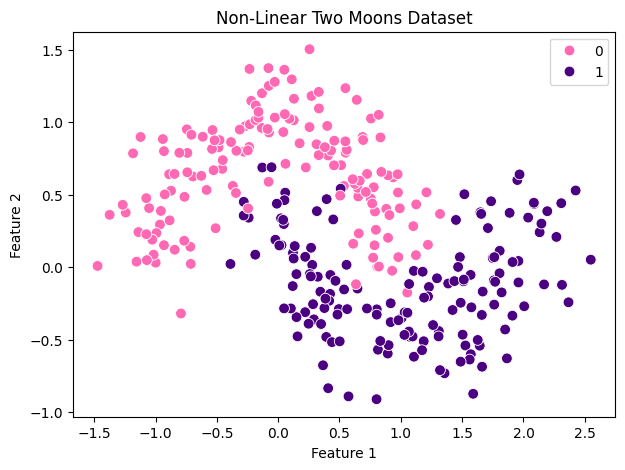

In [2]:
# Generate non-linearly separable "Two Moons" dataset
X, y = make_moons(n_samples=300, noise=0.20, random_state=42)

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Plot raw dataset in Pink/Purple Palette
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X[:, 0], y=X[:, 1], hue=y, palette=["#FF69B4", "#4B0082"], s=60
)
plt.title("Non-Linear Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## **Step 2: Implement RBF Network**

In [3]:
# Custom RBF Network Class
class RBFNetworkScratch:
    def __init__(self, num_centers=10, sigma=1.0):
        self.num_centers = num_centers
        self.sigma = sigma
        self.centers = None
        self.weights = None

    def _gaussian_rbf(self, x, center):
        """Compute Gaussian RBF distance activation"""
        distance = np.linalg.norm(x - center)
        return np.exp(-(distance**2) / (2 * (self.sigma**2)))

    def _calculate_phi_matrix(self, X):
        """Construct the Design Matrix Phi"""
        N = X.shape[0]
        Phi = np.zeros((N, self.num_centers))
        for i in range(N):
            for j in range(self.num_centers):
                Phi[i, j] = self._gaussian_rbf(X[i], self.centers[j])
        return Phi

    def fit(self, X, y):
        """Train RBF Network using KMeans and Pseudo-Inverse"""
        # 1. Find Centers using K-Means
        kmeans = KMeans(n_clusters=self.num_centers, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_

        # 2. Calculate Phi matrix
        Phi = self._calculate_phi_matrix(X)

        # 3. Add Bias column
        Phi_bias = np.hstack([Phi, np.ones((X.shape[0], 1))])

        # 4. Compute linear weights via pseudo-inverse
        self.weights = np.linalg.pinv(Phi_bias) @ y

    def predict(self, X):
        """Predict class labels"""
        Phi = self._calculate_phi_matrix(X)
        Phi_bias = np.hstack([Phi, np.ones((X.shape[0], 1))])
        raw_outputs = Phi_bias @ self.weights
        return np.where(raw_outputs >= 0.5, 1, 0)

## **Step 3: Train Model**

In [7]:
# Initialize RBF Network with 12 centers and spread sigma=0.8
rbf_model = RBFNetworkScratch(num_centers=12, sigma=0.8)

# Fit model on training data
rbf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rbf_model.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"RBF Model Accuracy: {accuracy * 100:.2f}%")

RBF Model Accuracy: 95.00%


## **Step 4: Visualize decision boundaries + cluster centers**

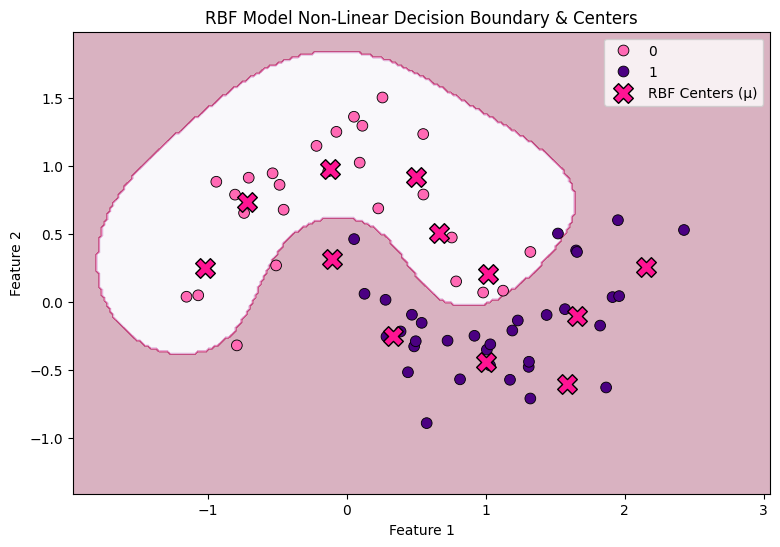

In [5]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over entire mesh grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = rbf_model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plotting decision boundary
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="PuRd")

# Scatter test data
sns.scatterplot(
    x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
    palette=["#FF69B4", "#4B0082"], s=60, edgecolor="k"
)

# Plot RBF Centers calculated by KMeans
plt.scatter(
    rbf_model.centers[:, 0], rbf_model.centers[:, 1],
    c="deeppink", marker="X", s=200, label="RBF Centers (μ)", edgecolor="black"
)

plt.title("RBF Model Non-Linear Decision Boundary & Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## **Step 5: Evaluate performance metrics**

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.94      0.97      0.96        34

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



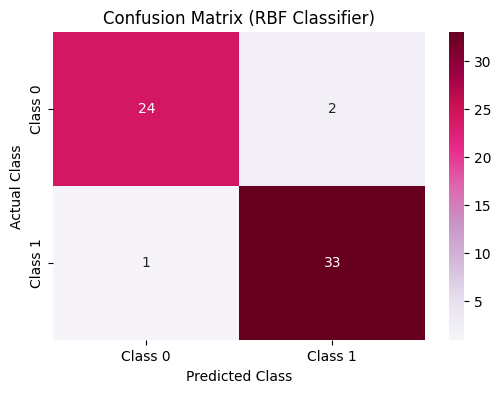

In [6]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix in PuRd colormap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd",
            xticklabels=["Class 0", "Class 1"],
            yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix (RBF Classifier)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## **Applications of RBF Models in Machine Learning**
* Function Approximation & Surface Interpolation: Fits continuous smooth hyper-surfaces to sparse multi-dimensional measurements.
* Time Series Forecasting: Used in stock market prediction, weather forecasting, and power load estimation due to fast adaptive learning capabilities.
* Pattern Classification & Speech Recognition: Effective in non-linear spatial mapping for voice recognition, handwriting identification, and biological signals (EEG/ECG).
* Adaptive Control Systems & Robotics: Applied in dynamic system modeling and real-time robotic motion tracking where ultra-fast training speeds are required.

## **Advantages and Disadvantages**

### **Advantages**
* Fast Training Speed: Unlike standard multi-layer perceptrons requiring thousands of backpropagation epochs, RBF computes output layer weights analytically via a single pseudo-inverse matrix operation.
* Non-Linear Separability: Efficiently maps low-dimensional, non-linearly separable inputs into higher-dimensional space where linear separation is achievable (Cover's Theorem).
* Local Activation: Gaussian RBF units only respond to inputs near their center, mitigating global interference during localized learning updates.

### **Disadvantages**
* Sensitivity to Centers and Bandwidth: Model accuracy depends heavily on selecting appropriate values for $M$ (number of centers) and $\sigma$ (spread parameter).
* Curse of Dimensionality: In high-dimensional spaces, computing Euclidean distances becomes computationally inefficient and less informative.